Options Price Modeling

In [21]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

Option Price Change

In [ ]:
### simple function for change in V ###

def calc_opt_price_change(delta, gamma, theta, dS, days=1):
    dV=theta*days + delta*dS + (1/2)*gamma*dS**2
    return dV

In [ ]:
### Black Scholes to calculate price from scratch

def bs_call_price(S, K, T, r, sigma):
    if T <= 0:
        return max(S - K, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

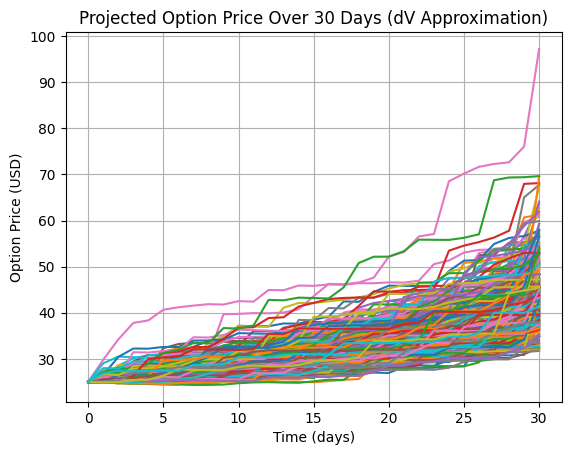

In [ ]:
### dv method (best for short term) ###

### sim params ###
shots = 300
time = 30
dt = 1 / 252

### underlying asset params ###
S0 = 100
mu = 0.10
sigma = 0.25

### option params ###
V0 = 25
delta0 = 0.272
gamma0 = 0.30
theta0 = -0.0053           # per day
T0 = 30 / 252        #days till exp

for _ in range(shots):
    S = S0
    V = V0

    days = [0]
    prices = [V0]

    for i in range(1, time + 1):
        z = np.random.normal(0, 1)
        dS = mu * S * dt + sigma * S * z * np.sqrt(dt)
        S += dS

        tau = max(T0 - (i - 1) * dt, 1e-6)

        # increase time decay
        theta_t = theta0 * np.sqrt(T0 / tau)
        gamma_t = gamma0 * np.sqrt(T0 / tau)
        delta_t = delta0   # fixed

        dV = calc_opt_price_change(delta_t, gamma_t, theta_t, dS, days=1)
        V = max(V + dV, 0)

        days.append(i)
        prices.append(V)

    plt.plot(days, prices)

plt.xlabel("Time (days)")
plt.ylabel("Option Price (USD)")
plt.title("Projected Option Price Over 30 Days (dV Approximation)")
plt.grid(True)
plt.show()

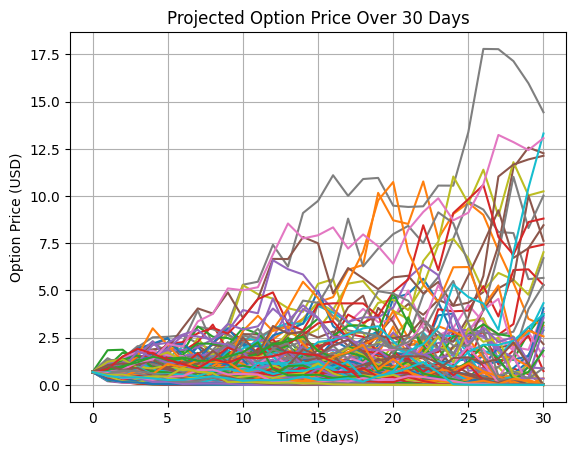

In [ ]:
### Calculate Options through daily repricing ###

# Parameters
shots = 300
time = 30
dt = 1 / 252
S0 = 100
K = 110
r = 0.04
sigma = 0.25
T0 = 30 / 252


for _ in range(shots):
    S = S0
    days = [0]
    prices = [bs_call_price(S, K, T0, r, sigma)]

    for i in range(1, time + 1):
        z = np.random.normal()
        S = S * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)
        T = max(T0 - i * dt, 0)
        V = bs_call_price(S, K, T, r, sigma)

        days.append(i)
        prices.append(V)
        final_price=V

    plt.plot(days, prices)

plt.xlabel("Time (days)")
plt.ylabel("Option Price (USD)")
plt.title("Projected Option Price Over 30 Days")
plt.grid(True)
plt.show()